In [1]:
# Plotting country mortality changes for each decade

In [2]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from utils.utils import autosize_figure, land_filter

In [3]:
# === Path config ===
MORT_DIR = "/glade/work/awells/air_quality/CESM/mortality/pm25/"

# === Main loop ===
ssp245_file = "PM2.5_Mortality_total_CESM_SSP245_2020-2069.nc"
ssp245_path = os.path.join(MORT_DIR, ssp245_file)
ssp245 = xr.open_dataarray(ssp245_path)

arise_file = "PM2.5_Mortality_total_CESM_ARISE_2035-2069.nc"
arise_path = os.path.join(MORT_DIR, arise_file)
arise = xr.open_dataarray(arise_path)

In [4]:
def create_global_country_map(da):
    # Path config
    MASKS_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"

    # Load in country mask
    mask_file = "GBD_Country_Masks_0.10.nc"
    mask_path = os.path.join(MASKS_DIR, mask_file)
    masks = xr.open_dataarray(mask_path)

    # Create DataArray filled with NaNs
    global_array = xr.DataArray(
        np.full((len(masks.lat), len(masks.lon)), np.nan),
        coords={"lat": masks.lat.values, "lon": masks.lon.values},
        dims=["lat", "lon"]
    )

    # Loop over countries, select the data for each country and apply to
    # empty array using the country mask
    for i in range(len(masks.country)):
        mask = masks.isel(country=i)
        country = masks.isel(country=i)["country"]
        mortality_country = da.sel(country=country)
        global_array = global_array.where(mask == 0, mortality_country)

    return global_array

In [5]:
difference = (arise - ssp245).mean("sample")

In [6]:
diff_30s = create_global_country_map(difference.sel(year=slice(2035, 2039)).mean(dim=("year", "ensemble")))
diff_40s = create_global_country_map(difference.sel(year=slice(2040, 2049)).mean(dim=("year", "ensemble")))
diff_50s = create_global_country_map(difference.sel(year=slice(2050, 2059)).mean(dim=("year", "ensemble")))
diff_60s = create_global_country_map(difference.sel(year=slice(2060, 2068)).mean(dim=("year", "ensemble")))

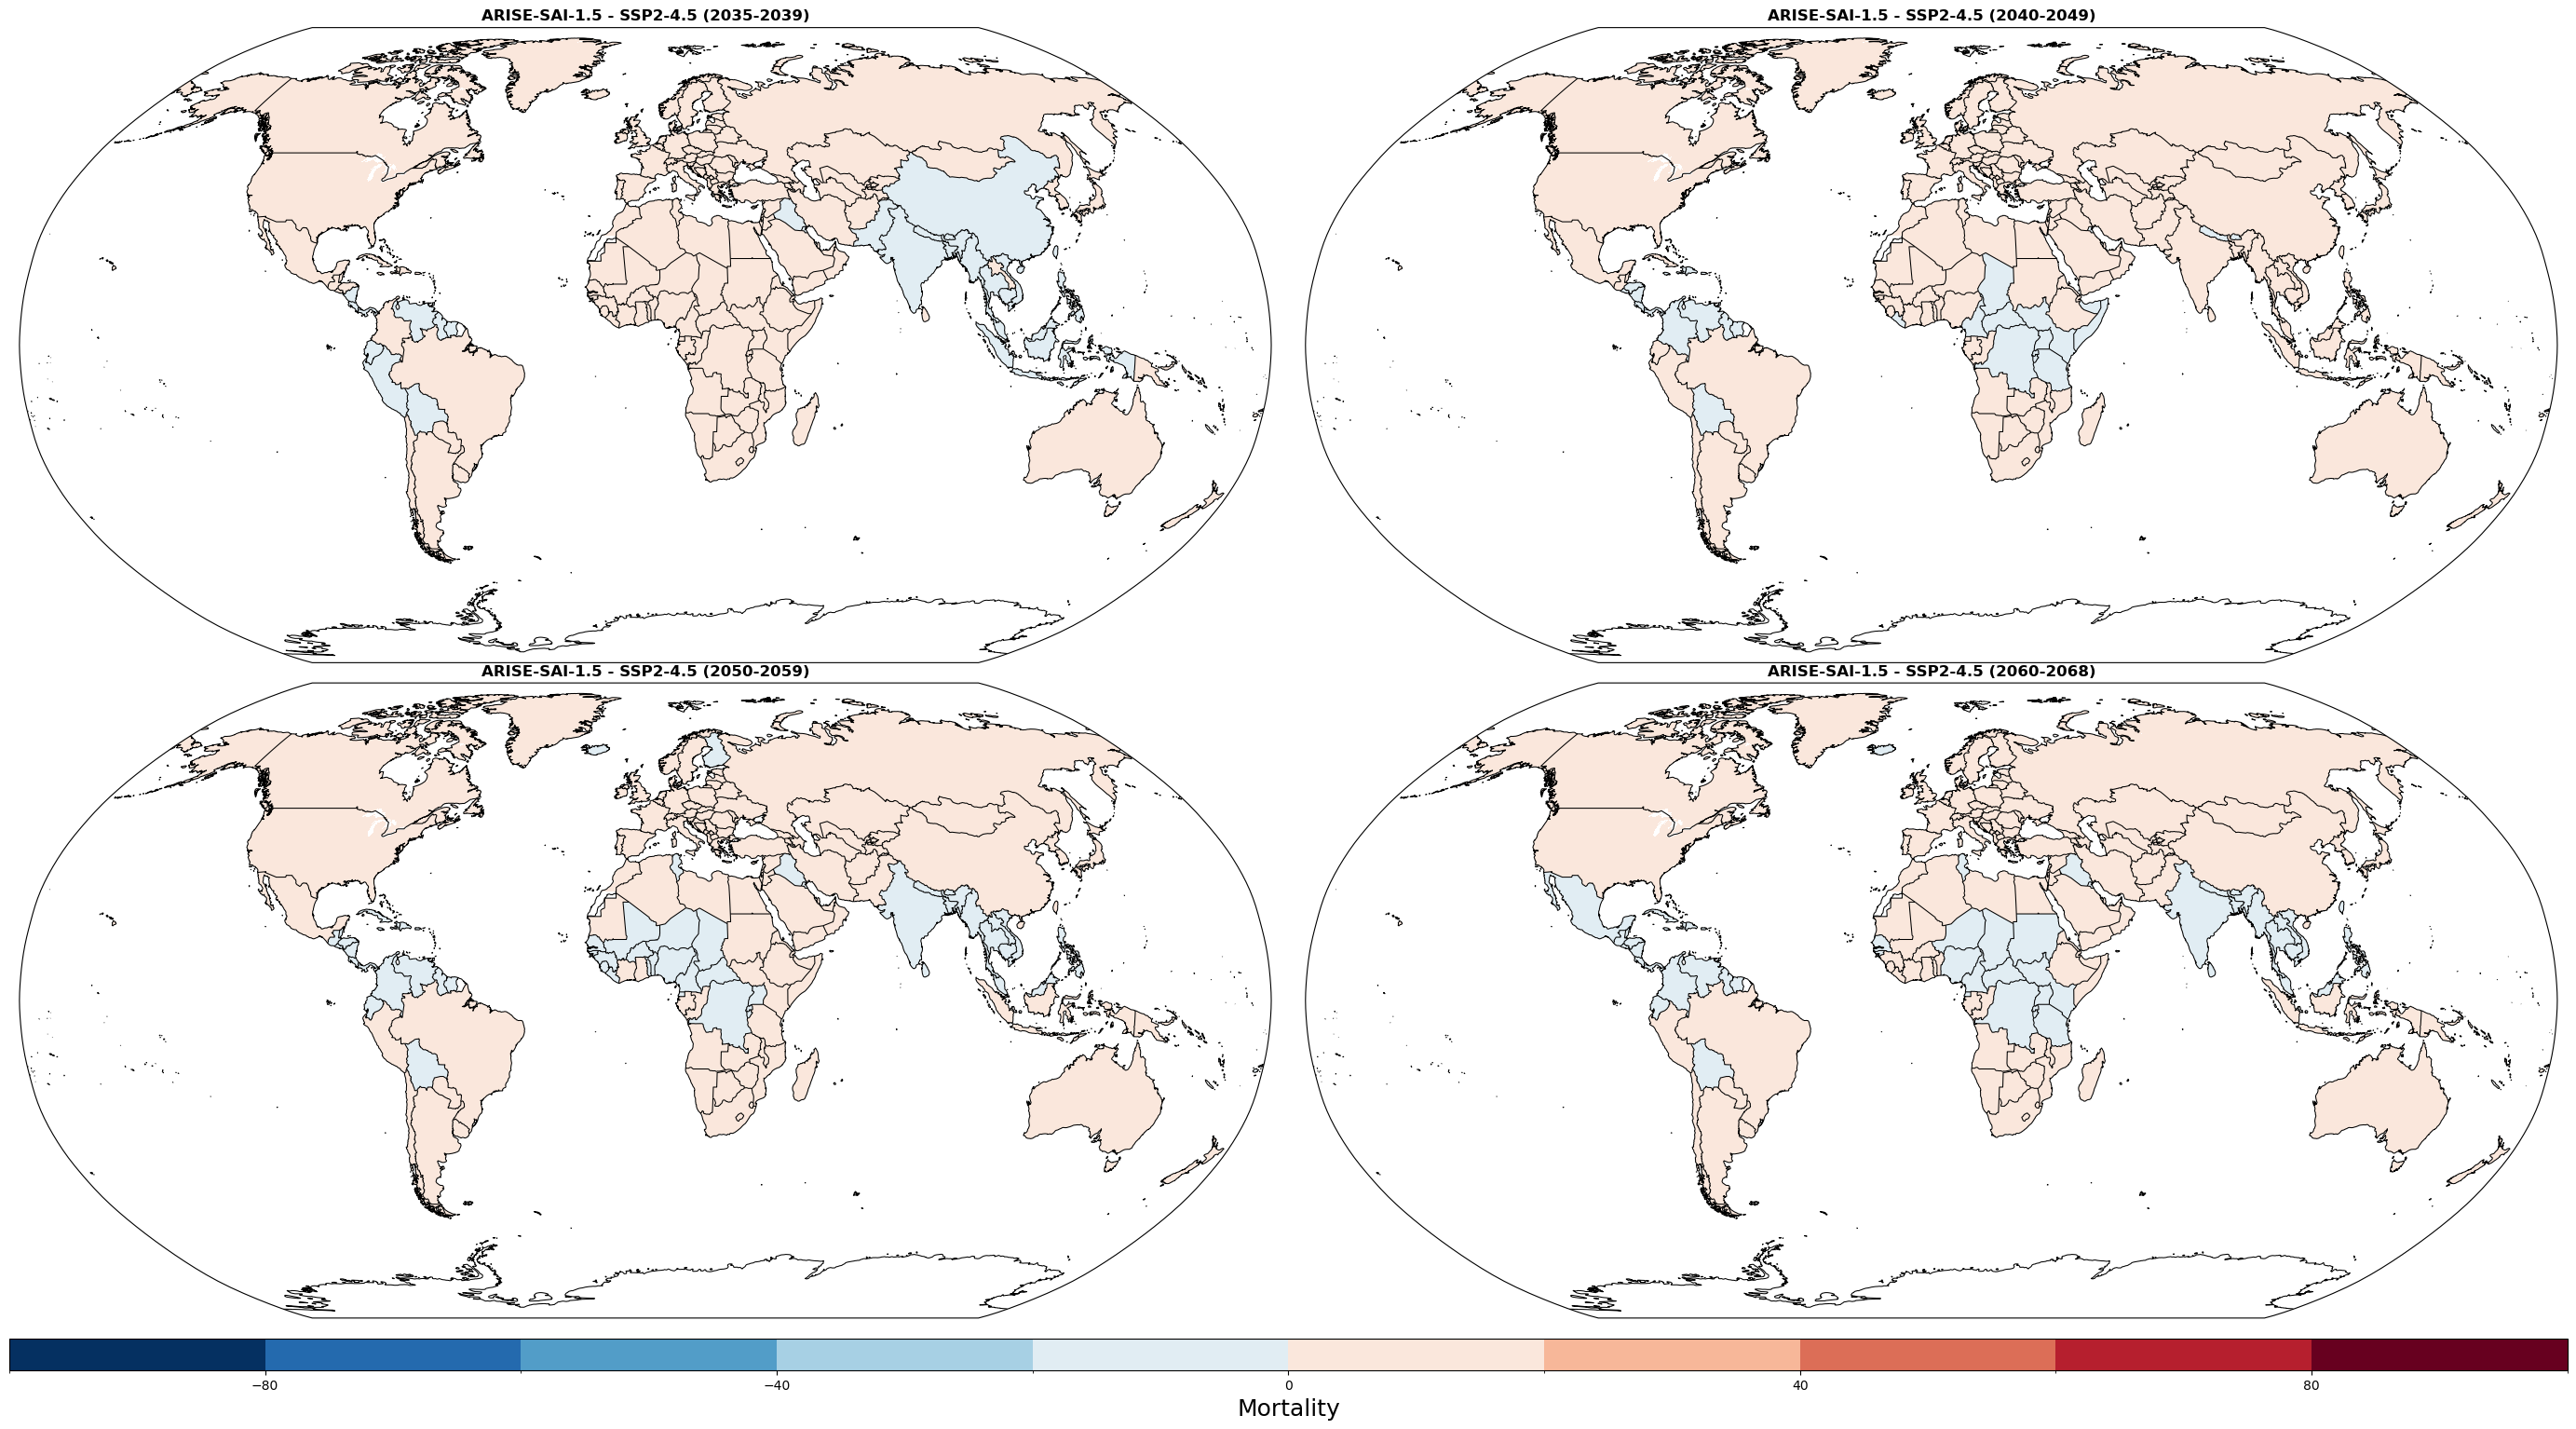

In [8]:
fig = plt.figure(figsize=autosize_figure(2, 2, scale_factor=1.6, xscale_factor=1.3))
gs = GridSpec(3, 2, height_ratios=[20, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

levels = [-100, -80, -60, -40, -20, 0, 20, 40, 60, 80, 100]

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(diff_30s).plot(transform=crs, levels=levels,
                                add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2035-2039)", fontweight='bold')

# Second panel
ax = fig.add_subplot(gs[0, 1], projection=projection, frameon=True)
cb = land_filter(diff_40s).plot(transform=crs, levels=levels,
                                add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2040-2049)", fontweight='bold')

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = land_filter(diff_50s).plot(transform=crs, levels=levels,
                                add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2050-2059)", fontweight='bold')

# Fourth panel
ax = fig.add_subplot(gs[1, 1], projection=projection, frameon=True)
cb = land_filter(diff_60s).plot(transform=crs, levels=levels,
                                add_colorbar=False, subplot_kws={'projection': projection})
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2060-2068)", fontweight='bold')

# Colorbar
cax = fig.add_subplot(gs[2, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('Mortality', fontsize=18)

plt.tight_layout()